In [1]:
import pandas as pd
import glob
import os
import re

base_dir = os.path.dirname(os.path.abspath("analyze.ipynb"))

records = []

for family_dir in sorted(glob.glob(os.path.join(base_dir, "*"))):
    if not os.path.isdir(family_dir):
        continue
    family = os.path.basename(family_dir)
    if family.startswith("fol"):
        continue

    for datasize_dir in sorted(glob.glob(os.path.join(family_dir, "results", "datasize_*"))):
        match = re.search(r"datasize_([0-9.]+)$", datasize_dir)
        if not match:
            continue
        percent = float(match.group(1))

        for dat_file in sorted(glob.glob(os.path.join(datasize_dir, "*.dat"))):
            df = pd.read_csv(dat_file)
            df["family"] = family
            df["percent"] = percent
            df["seed_file"] = os.path.basename(dat_file)
            records.append(df)

df_all = pd.concat(records, ignore_index=True)
print(df_all.shape)
df_all.head()


(1440, 11)


,steps,ctot,metaCtot,gittinsCtot,inferenceCtot,numObjects,numSkeletons,success,family,percent,seed_file
0,16,2.84842,18.2056,0.05571,18.1497,2,5,1,obj2_2_goals2_blocked2,0.2,GITTINS_30_5_p0.2_ms10_0303_074658.STOP.dat
1,13,0.836048,0.419968,0.038899,0.380952,2,5,1,obj2_2_goals2_blocked2,0.2,GITTINS_30_5_p0.2_ms10_0303_074658.STOP.dat
2,39,4.13803,0.425939,0.045829,0.379971,2,5,1,obj2_2_goals2_blocked2,0.2,GITTINS_30_5_p0.2_ms10_0303_074658.STOP.dat
3,26,1.84216,0.426214,0.047569,0.378517,2,5,1,obj2_2_goals2_blocked2,0.2,GITTINS_30_5_p0.2_ms10_0303_074658.STOP.dat
4,137,7.85153,0.630962,0.094325,0.536448,2,5,1,obj2_2_goals2_blocked2,0.2,GITTINS_30_5_p0.2_ms10_0303_074658.STOP.dat


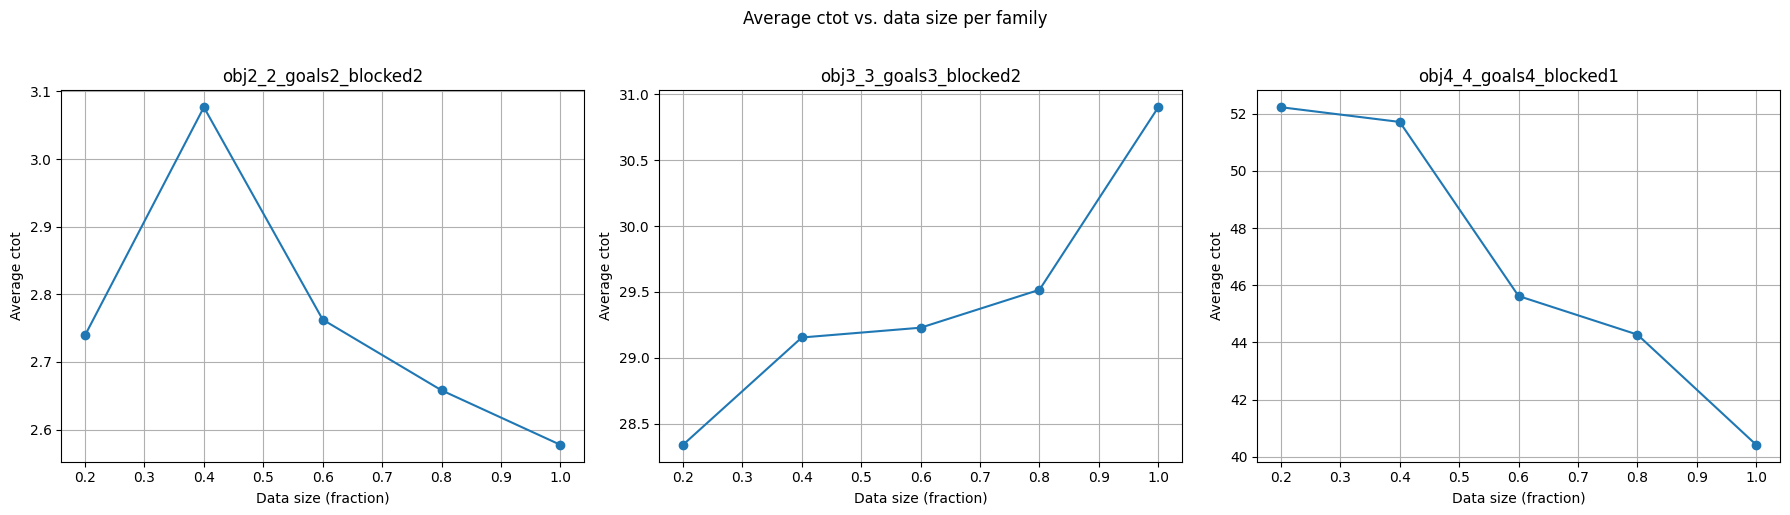

In [3]:
import matplotlib.pyplot as plt

grouped = df_all.groupby(["family", "percent"])["ctot"].mean().reset_index()

families = sorted(grouped["family"].unique())
fig, axes = plt.subplots(1, len(families), figsize=(6 * len(families), 5))

if len(families) == 1:
    axes = [axes]

for ax, family in zip(axes, families):
    fdata = grouped[grouped["family"] == family].sort_values("percent")
    ax.plot(fdata["percent"], fdata["ctot"], marker="o")
    ax.set_xlabel("Data size (fraction)")
    ax.set_ylabel("Average ctot")
    ax.set_title(family)
    ax.grid(True)

plt.suptitle("Average ctot vs. data size per family", y=1.02)
plt.tight_layout()
plt.show()
